# Simple Flow Matching on MNIST dataset

In this notebook a simple implementation of the flow matching algorithm is presented; we'll try to generate some letter from the MNIST dataset. We'll see how this algorithm is fast in doing so.

Importing packages...

In [ ]:
import torch
from torch import nn, Tensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt 
import numpy as np

Importing the MNIST dataset 

In [ ]:
batch_size = 256
transform = transforms.Compose([
    transforms.ToTensor(),
])
mnist_all = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
indices_9 = [i for i, (_, label) in enumerate(mnist_all) if label == 9]

Define array for training

In [ ]:
train_array = np.zeros((len(indices_9), 784))
count = 0
for idx in indices_9:
    train_array[count] = mnist_all[idx][0].reshape(784)
    count = count + 1

# Flow Model
This model is the NN that should be an approximation of the Velocity Model u_t. This is a simple MLP composed of three hidden layers and using ELU non linearity for each.
The function forward is used in traing, the function step is used in inference time (image generation); the latter uses Euler's Method with midpoint solution to compute the t_end timestep given the t_start time and the image at t_start (x_t).

In [ ]:
class Flow(nn.Module):
    def __init__(self, dim: int = 784, h: int = 2096):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim)
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            t_start + (t_end - t_start) / 2
        )


Training of the model; simple training using ADAMW optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

flow = Flow()
optimizer = torch.optim.AdamW(flow.parameters(), 1e-3, weight_decay=0.01)
loss_fn = nn.MSELoss()

for idx in range(30000):
    x_1 = Tensor(train_array)[torch.randperm(Tensor(train_array).size(0))[:256]].to(device)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1).to(device)
    x_t = t * x_0 + t * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    loss = loss_fn(flow(x_t, t), dx_t)
    loss.backward()
    optimizer.step()

    print(f"Epoch : {idx}, loss = {loss.item():.4f}")


Image Generation - select an arbitrary value for n_steps

C:\Users\ernid\AppData\Local\Temp\ipykernel_10972\3595096997.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  axes[i + 1].imshow(np.array(x.reshape((28, 28)).detach()), cmap="gray", vmin=0, vmax=1)


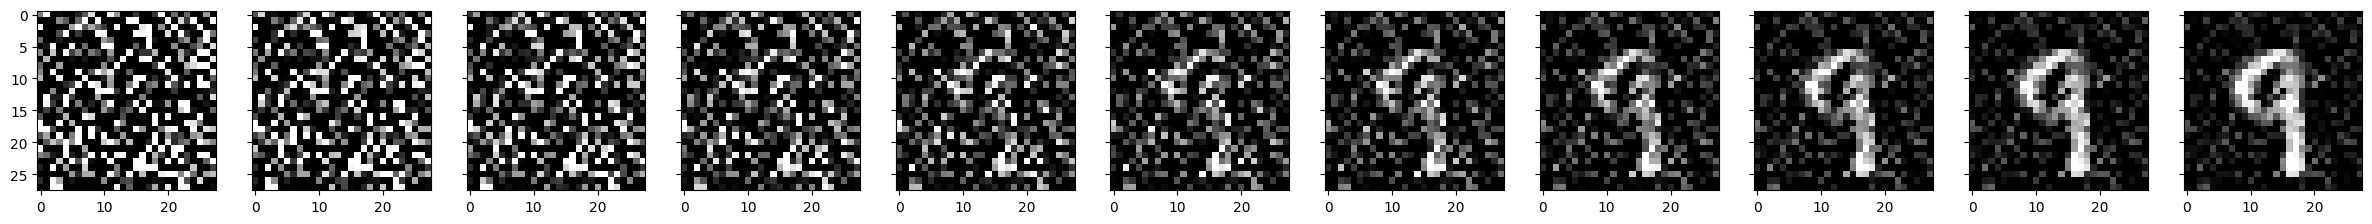

In [50]:
x = torch.randn(1, 784).to(device)
n_steps = 10
time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)

fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
axes[0].imshow(x.reshape((28, 28)), cmap="gray", vmin=0, vmax=1)

for i in range(n_steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])
    axes[i + 1].imshow(np.array(x.reshape((28, 28)).detach()), cmap="gray", vmin=0, vmax=1)

plt.show()